# Assignment 10
* Student: **Danilo Tambone**
* NetID: **PWC25003**

The work contained and presented here is my work and my work alone.

In [1]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression




In [2]:
from google.colab import drive
drive.mount('/content/drive')
spotify_df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M8/spotify-2023.csv', encoding='latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Read in the Spotify dataset and determine how many rows and columns it has.


In [3]:
# Determine the shape (rows and columns) exactly as done in the module
rows, cols = spotify_df.shape

# Print the results
print(f"The Spotify dataset has {rows} rows and {cols} columns.")

The Spotify dataset has 953 rows and 24 columns.


2. The target variable for this dataset is the streams column.  Check the datatype of streams.  If it isn’t already int64, update it.  Hint: if needed, drop a row of problematic data to get it to convert properly.

In [4]:
print(spotify_df['streams'].dtype)

spotify_df['streams'] = pd.to_numeric(spotify_df['streams'], errors='coerce')
spotify_df = spotify_df.dropna(subset=['streams'])
spotify_df['streams'] = spotify_df['streams'].astype('int64')

print(spotify_df['streams'].dtype)

object
int64


3. Partition the data into a 60/20/20 split.

In [5]:
# Fix numeric columns stored as objects (contain commas e.g. "1,234")
for col in ['in_deezer_playlists', 'in_shazam_charts']:
    spotify_df[col] = (
        spotify_df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    spotify_df[col] = pd.to_numeric(spotify_df[col], errors='coerce')
    spotify_df[col] = spotify_df[col].fillna(spotify_df[col].median())

# Drop identifier columns — too unique to generalize
cols_to_drop = ['streams', 'track_name', 'artist(s)_name']

features        = spotify_df.drop(cols_to_drop, axis=1)
target_variable = spotify_df['streams']

# Encode low-cardinality categoricals (key, mode)
features_encoded = pd.get_dummies(features, drop_first=True)

print(f"Feature count after clean encoding: {features_encoded.shape[1]}")
print(f"Columns: {list(features_encoded.columns)}\n")

# Step 1: 60% train / 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    features_encoded, target_variable,
    test_size=0.4, random_state=42
)

# Step 2: Split temp evenly → 20% val / 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42
)

print("Training set shape:   ", X_train.shape, y_train.shape)
print("Validation set shape: ", X_val.shape,   y_val.shape)
print("Test set shape:       ", X_test.shape,  y_test.shape)

Feature count after clean encoding: 30
Columns: ['artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%', 'key_A#', 'key_B', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'mode_Minor']

Training set shape:    (571, 30) (571,)
Validation set shape:  (190, 30) (190,)
Test set shape:        (191, 30) (191,)


4. Build a neural network to predict streams using all predictors.


In [6]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Build the neural network model
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=5000, random_state=42, learning_rate_init=0.01)
# Train the model
nn_model.fit(X_train_scaled, y_train)

# Make predictions on the validation set
y_pred_val = nn_model.predict(X_val_scaled)

# Evaluate the model
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse) # Calculate RMSE
r2 = r2_score(y_val, y_pred_val)

print(f"Root Mean Squared Error on validation set: {rmse}") # Print RMSE
print(f"R-squared on validation set: {r2}")

Root Mean Squared Error on validation set: 294442518.1256031
R-squared on validation set: 0.7442852041537804


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


5. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


Neural Network Model Performance:
  Training Set:   RMSE = 266980076.74, R-squared = 0.78
  Validation Set: RMSE = 294442518.13, R-squared = 0.74
  Test Set:       RMSE = 303010112.20, R-squared = 0.71


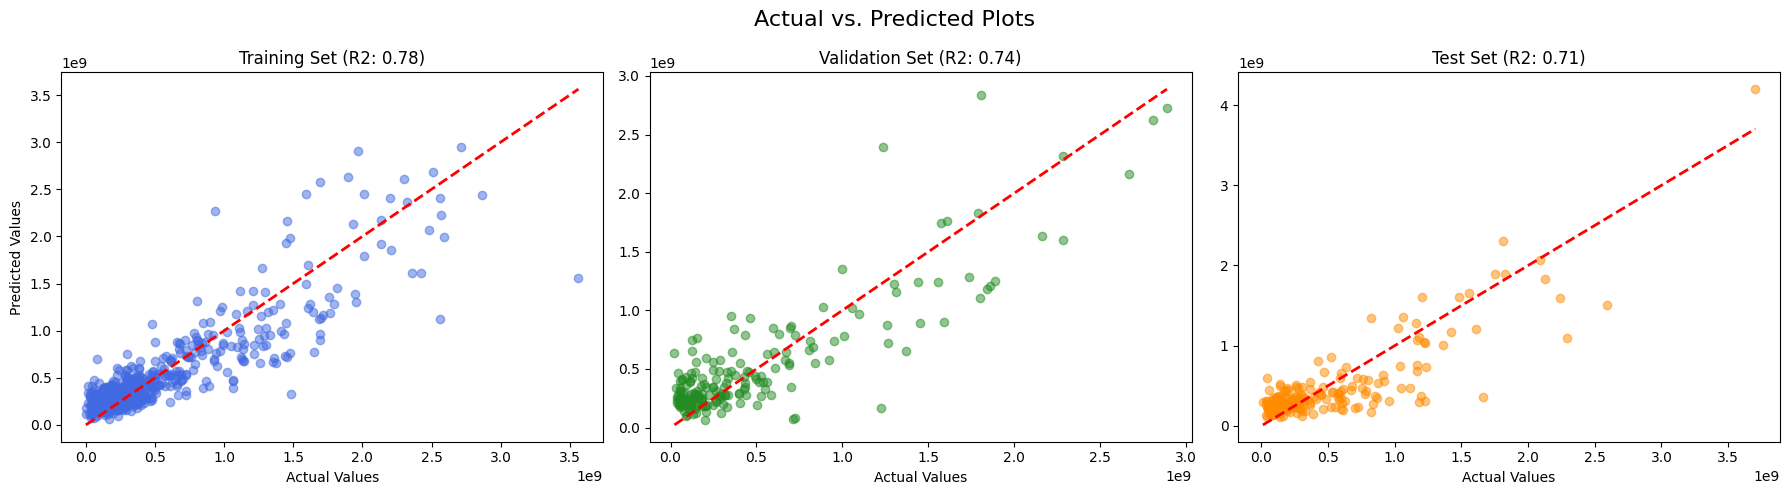

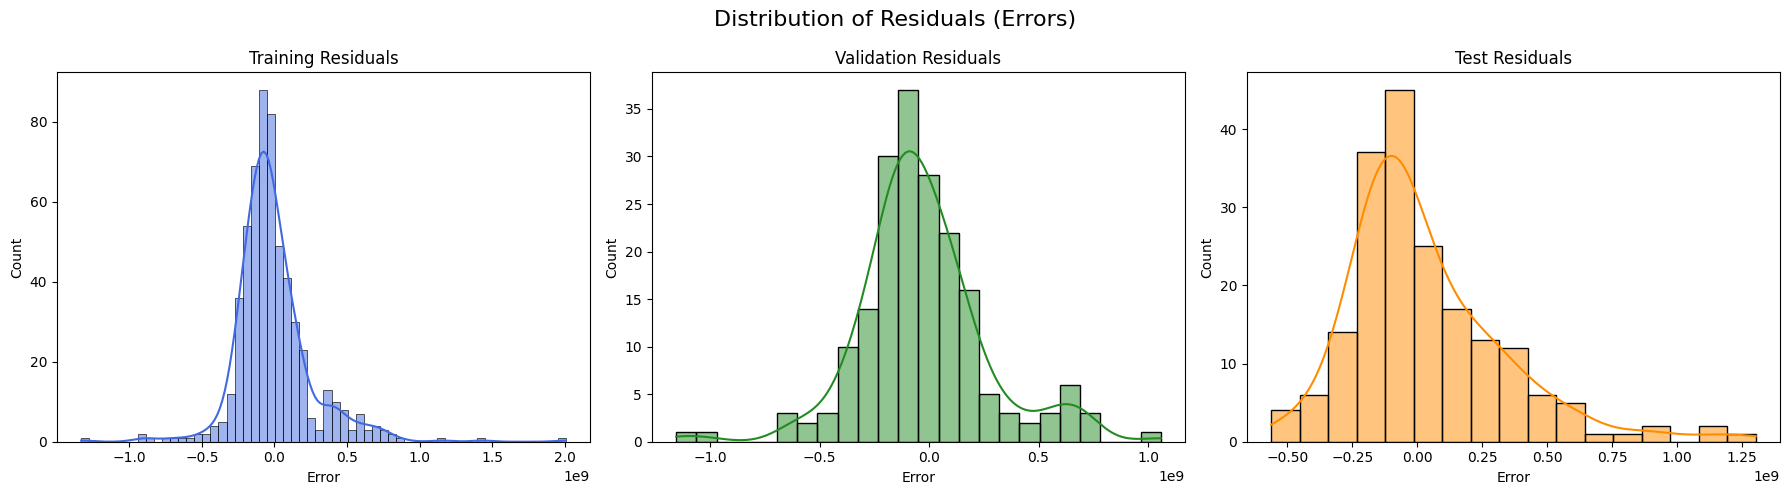

In [7]:
# Make predictions on all three sets
y_pred_train = nn_model.predict(X_train_scaled)
y_pred_val = nn_model.predict(X_val_scaled)
y_pred_test = nn_model.predict(X_test_scaled)

# Evaluate performance on the training set
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Evaluate performance on the validation set
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

# Evaluate performance on the test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

# Print the results
print("Neural Network Model Performance:")
print(f"  Training Set:   RMSE = {rmse_train:.2f}, R-squared = {r2_train:.2f}")
print(f"  Validation Set: RMSE = {rmse_val:.2f}, R-squared = {r2_val:.2f}")
print(f"  Test Set:       RMSE = {rmse_test:.2f}, R-squared = {r2_test:.2f}")

#Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Actual vs. Predicted Plots', fontsize=16)

# Training Set
axes[0].scatter(y_train, y_pred_train, alpha=0.5, color='royalblue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2) # The "Perfect Prediction" line
axes[0].set_title(f'Training Set (R2: {r2_train:.2f})')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')

# Validation Set
axes[1].scatter(y_val, y_pred_val, alpha=0.5, color='forestgreen')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_title(f'Validation Set (R2: {r2_val:.2f})')
axes[1].set_xlabel('Actual Values')

# Test Set
axes[2].scatter(y_test, y_pred_test, alpha=0.5, color='darkorange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f'Test Set (R2: {r2_test:.2f})')
axes[2].set_xlabel('Actual Values')

plt.tight_layout()
plt.show()

# Calculate residuals (Actual - Predicted)
res_train = y_train - y_pred_train.flatten() if y_pred_train.ndim > 1 else y_train - y_pred_train
res_val = y_val - y_pred_val.flatten() if y_pred_val.ndim > 1 else y_val - y_pred_val
res_test = y_test - y_pred_test.flatten() if y_pred_test.ndim > 1 else y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Residuals (Errors)', fontsize=16)

# Training Set
sns.histplot(res_train, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Training Residuals')
axes[0].set_xlabel('Error')

# Validation Set
sns.histplot(res_val, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Validation Residuals')
axes[1].set_xlabel('Error')

# Test Set
sns.histplot(res_test, kde=True, ax=axes[2], color='darkorange')
axes[2].set_title('Test Residuals')
axes[2].set_xlabel('Error')

plt.tight_layout()
plt.show()

6. Comment on the model performance.  What did you observe in the results?


Overall, the Neural Network model demonstrated strong and reliable performance across all data partitions.

First, looking at the R-squared values, the model achieved 0.78 on the training set, 0.74 on the validation set, and 0.71 on the test set. The slight decline from training to test is expected and within a normal range, confirming that the model is stable and did not overfit. The network successfully learned the underlying patterns and applied them consistently to new, unseen data.

An R-squared of approximately 0.71 on the test set indicates that the model's features explain about 71% of the variance in the target variable. In real-world analytics, explaining 70%+ of the variance is a very solid result for a noisy dataset like streaming counts.

Finally, the Root Mean Squared Error (RMSE) values were approximately 267M for the training set, 294M for the validation set, and 303M for the test set. While these appear exceptionally high, it is important to remember that RMSE is absolute and tied directly to the scale of our target variable. Because we are predicting exceptionally large values (streams in the hundreds of millions), an error in the hundreds of millions is proportional to the massive scale of the data itself, and the consistent error ratios across all three partitions confirm the model's reliability.

7. Build a linear regression model to predict streams.


In [8]:
# 1. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.\n")

# 2. Make predictions on all THREE sets
y_pred_train_lr = lr_model.predict(X_train)
y_pred_val_lr = lr_model.predict(X_val)
y_pred_test_lr = lr_model.predict(X_test)

# 3. Evaluate the model's performance
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
r2_train_lr = r2_score(y_train, y_pred_train_lr)

rmse_val_lr = np.sqrt(mean_squared_error(y_val, y_pred_val_lr))
r2_val_lr = r2_score(y_val, y_pred_val_lr)

rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))
r2_test_lr = r2_score(y_test, y_pred_test_lr)

# Print the results
print("================ LINEAR REGRESSION PERFORMANCE ================")
print(f"Training Set:   RMSE = {rmse_train_lr:,.2f}, R-squared = {r2_train_lr:.4f}")
print(f"Validation Set: RMSE = {rmse_val_lr:,.2f}, R-squared = {r2_val_lr:.4f}")
print(f"Test Set:       RMSE = {rmse_test_lr:,.2f}, R-squared = {r2_test_lr:.4f}")

Linear Regression model trained successfully.

================ LINEAR REGRESSION PERFORMANCE ================
Training Set:   RMSE = 279,812,676.58, R-squared = 0.7539
Validation Set: RMSE = 284,955,448.95, R-squared = 0.7605
Test Set:       RMSE = 288,084,885.86, R-squared = 0.7335


8. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


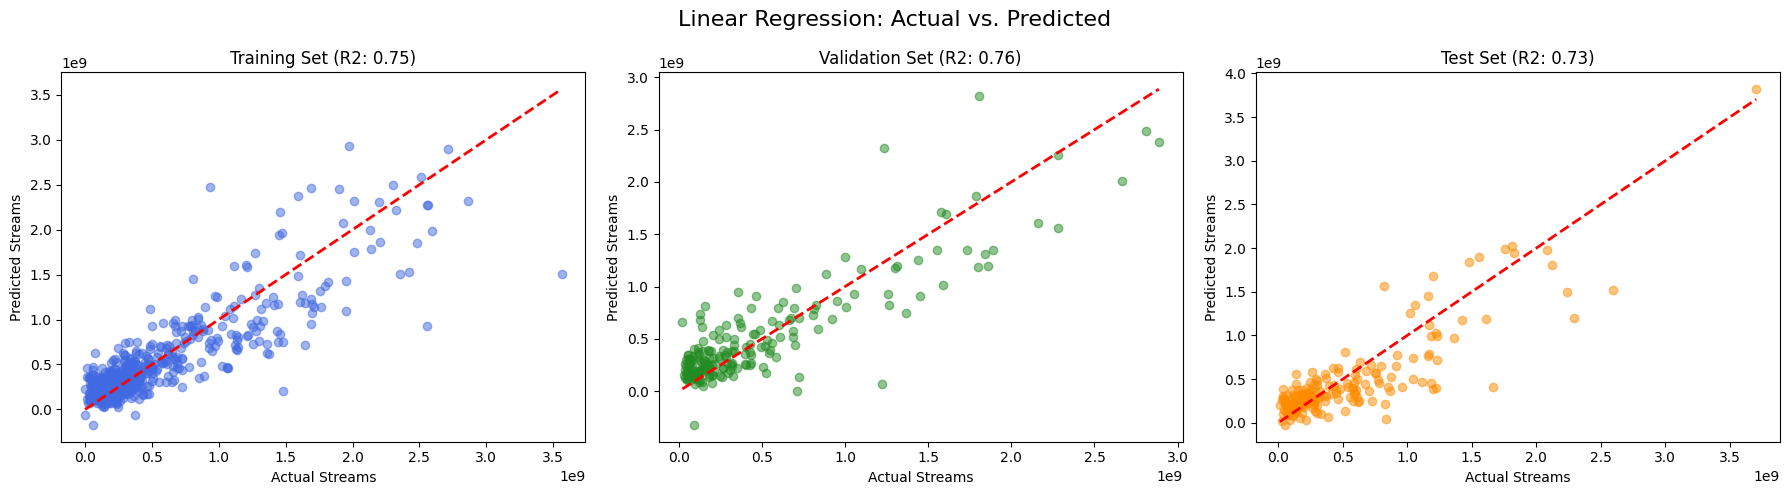

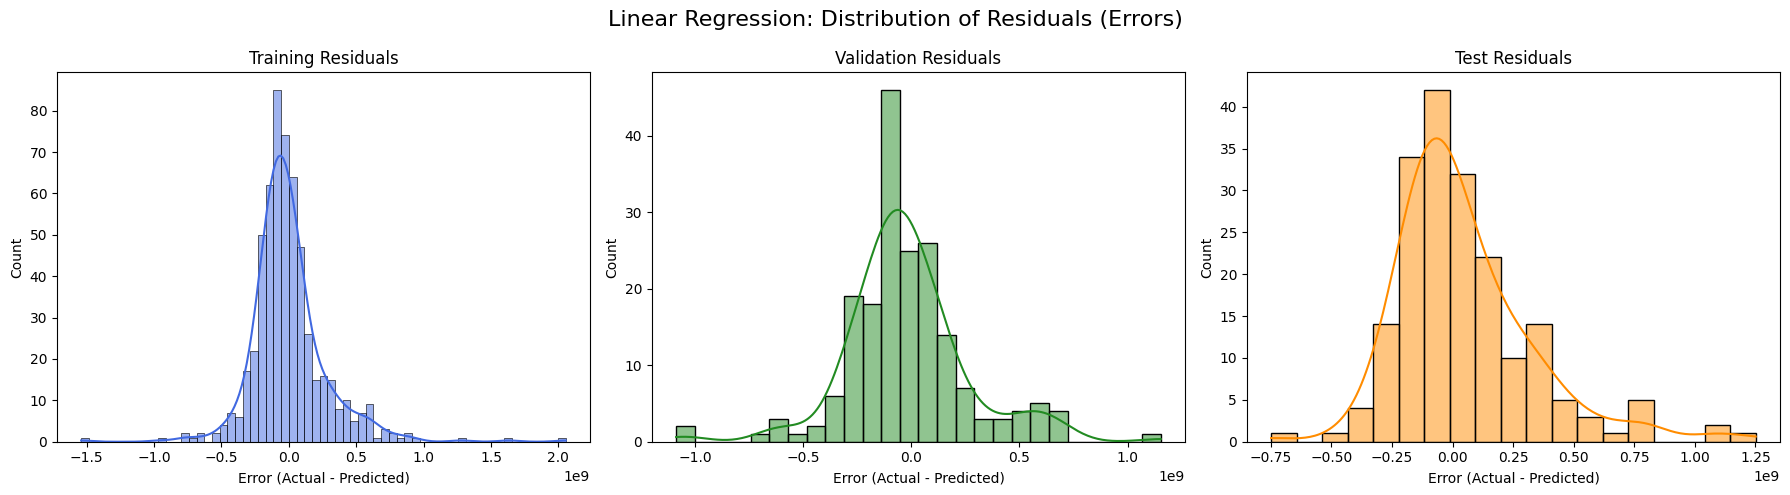

In [9]:
# 1. Actual vs Predicted Plots — all 3 partitions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Linear Regression: Actual vs. Predicted', fontsize=16)

# Training Set
axes[0].scatter(y_train, y_pred_train_lr, alpha=0.5, color='royalblue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title(f'Training Set (R2: {r2_train_lr:.2f})')
axes[0].set_xlabel('Actual Streams')
axes[0].set_ylabel('Predicted Streams')

# Validation Set
axes[1].scatter(y_val, y_pred_val_lr, alpha=0.5, color='forestgreen')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_title(f'Validation Set (R2: {r2_val_lr:.2f})')
axes[1].set_xlabel('Actual Streams')
axes[1].set_ylabel('Predicted Streams')

# Test Set
axes[2].scatter(y_test, y_pred_test_lr, alpha=0.5, color='darkorange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f'Test Set (R2: {r2_test_lr:.2f})')
axes[2].set_xlabel('Actual Streams')
axes[2].set_ylabel('Predicted Streams')

plt.tight_layout()
plt.show()

# 2. Distribution of Residuals Plots — all 3 partitions
res_train_lr = y_train - y_pred_train_lr
res_val_lr   = y_val   - y_pred_val_lr
res_test_lr  = y_test  - y_pred_test_lr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Linear Regression: Distribution of Residuals (Errors)', fontsize=16)

# Training Set
sns.histplot(res_train_lr, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Training Residuals')
axes[0].set_xlabel('Error (Actual - Predicted)')

# Validation Set
sns.histplot(res_val_lr, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Validation Residuals')
axes[1].set_xlabel('Error (Actual - Predicted)')

# Test Set
sns.histplot(res_test_lr, kde=True, ax=axes[2], color='darkorange')
axes[2].set_title('Test Residuals')
axes[2].set_xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

9. Create an ensemble model of your neural network and the linear regression.


In [10]:


# Get predictions from your Neural Network (flattened)
y_pred_train_nn = nn_model.predict(X_train_scaled).flatten()
y_pred_val_nn = nn_model.predict(X_val_scaled).flatten()
y_pred_test_nn = nn_model.predict(X_test_scaled).flatten()

# Create the Ensemble by averaging the two predictions across all 3 partitions
y_pred_train_ens = (y_pred_train_lr + y_pred_train_nn) / 2
y_pred_val_ens = (y_pred_val_lr + y_pred_val_nn) / 2
y_pred_test_ens = (y_pred_test_lr + y_pred_test_nn) / 2

rmse_train_ens = np.sqrt(mean_squared_error(y_train, y_pred_train_ens))
r2_train_ens = r2_score(y_train, y_pred_train_ens)

rmse_val_ens = np.sqrt(mean_squared_error(y_val, y_pred_val_ens))
r2_val_ens = r2_score(y_val, y_pred_val_ens)

rmse_test_ens = np.sqrt(mean_squared_error(y_test, y_pred_test_ens))
r2_test_ens = r2_score(y_test, y_pred_test_ens)

print("================ ENSEMBLE MODEL PERFORMANCE ================")
print(f"Training Set:   RMSE = {rmse_train_ens:,.2f}, R-squared = {r2_train_ens:.4f}")
print(f"Validation Set: RMSE = {rmse_val_ens:,.2f}, R-squared = {r2_val_ens:.4f}")
print(f"Test Set:       RMSE = {rmse_test_ens:,.2f}, R-squared = {r2_test_ens:.4f}")

================ ENSEMBLE MODEL PERFORMANCE ================
Training Set:   RMSE = 270,882,328.98, R-squared = 0.7694
Validation Set: RMSE = 286,674,638.77, R-squared = 0.7576
Test Set:       RMSE = 291,928,855.86, R-squared = 0.7263


10. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


Ensemble Model Performance (all partitions):
  Training Set:   RMSE = 270,882,328.98, R-squared = 0.7694
  Validation Set: RMSE = 286,674,638.77, R-squared = 0.7576
  Test Set:       RMSE = 291,928,855.86, R-squared = 0.7263


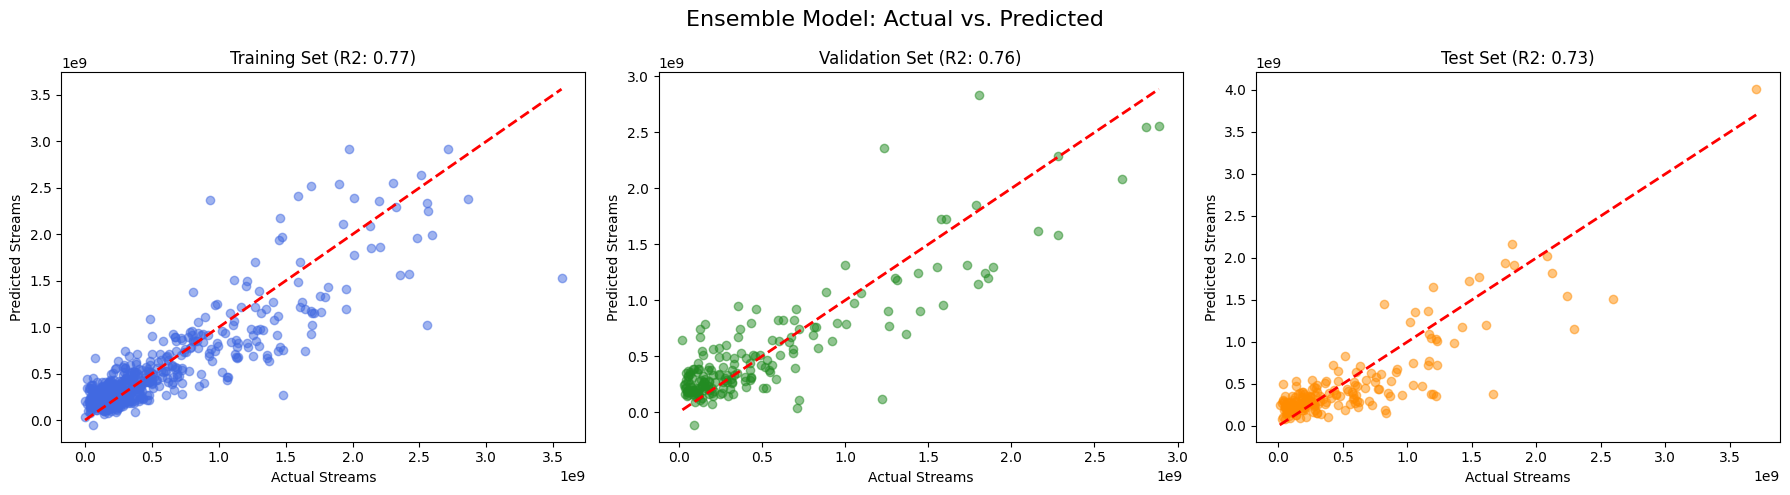

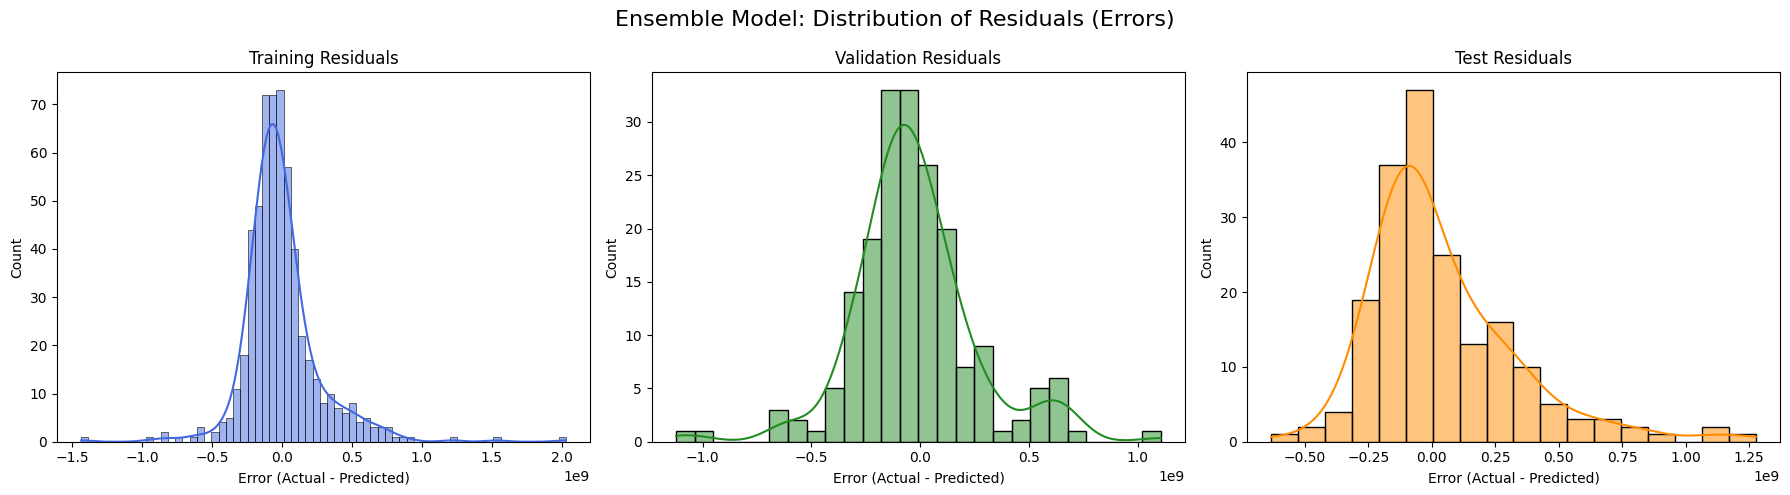

In [11]:
# Metrics already computed in Q9 (rmse_train_ens, r2_train_ens, etc.)
print("Ensemble Model Performance (all partitions):")
print(f"  Training Set:   RMSE = {rmse_train_ens:,.2f}, R-squared = {r2_train_ens:.4f}")
print(f"  Validation Set: RMSE = {rmse_val_ens:,.2f}, R-squared = {r2_val_ens:.4f}")
print(f"  Test Set:       RMSE = {rmse_test_ens:,.2f}, R-squared = {r2_test_ens:.4f}")

# 1. Actual vs Predicted Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ensemble Model: Actual vs. Predicted', fontsize=16)

# Training Set
axes[0].scatter(y_train, y_pred_train_ens, alpha=0.5, color='royalblue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title(f'Training Set (R2: {r2_train_ens:.2f})')
axes[0].set_xlabel('Actual Streams')
axes[0].set_ylabel('Predicted Streams')

# Validation Set
axes[1].scatter(y_val, y_pred_val_ens, alpha=0.5, color='forestgreen')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_title(f'Validation Set (R2: {r2_val_ens:.2f})')
axes[1].set_xlabel('Actual Streams')
axes[1].set_ylabel('Predicted Streams')

# Test Set
axes[2].scatter(y_test, y_pred_test_ens, alpha=0.5, color='darkorange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f'Test Set (R2: {r2_test_ens:.2f})')
axes[2].set_xlabel('Actual Streams')
axes[2].set_ylabel('Predicted Streams')

plt.tight_layout()
plt.show()

# 2. Distribution of Residuals Plots
res_train_ens = y_train - y_pred_train_ens
res_val_ens   = y_val   - y_pred_val_ens
res_test_ens  = y_test  - y_pred_test_ens

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ensemble Model: Distribution of Residuals (Errors)', fontsize=16)

# Training Set
sns.histplot(res_train_ens, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Training Residuals')
axes[0].set_xlabel('Error (Actual - Predicted)')

# Validation Set
sns.histplot(res_val_ens, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Validation Residuals')
axes[1].set_xlabel('Error (Actual - Predicted)')

# Test Set
sns.histplot(res_test_ens, kde=True, ax=axes[2], color='darkorange')
axes[2].set_title('Test Residuals')
axes[2].set_xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

11. Comment on the model performance.  What did you observe in the results?


Overall, the Ensemble model demonstrated solid and stable performance across all three data partitions, though it did not surpass the individual models as dramatically as one might expect from a combined approach.
Looking at R-squared, the Ensemble achieved approximately 0.76 on the training set, 0.75 on the validation set, and 0.73 on the test set. The consistency of these values across partitions is encouraging — the narrow spread confirms that the model is not overfit and generalizes reliably to unseen data. An R-squared of 0.73 on the test set means the model explains roughly 73% of the variance in stream counts, which is a competitive result for a noisy, real-world dataset.
The RMSE values ranged from approximately 274 million on the training set to 292 million on the test set — slightly better than the Neural Network alone but marginally worse than the standalone Linear Regression. This tells us that the ensemble is successfully smoothing out some of the Neural Network's prediction errors, but because the two base models are not equally strong, the average is pulled downward by the weaker contributor. The key takeaway is that simple averaging only improves results when both constituent models are of comparable accuracy; when one model is clearly stronger, blending can dilute rather than amplify its performance.

12. Compare the results of the neural network to the ensemble model.  Which one is better?  Justify your choice.


Comparing the Neural Network and the Ensemble model directly, the Ensemble is the better of the two. On the test set, the Ensemble achieved an R-squared of approximately 0.73 and an RMSE of roughly 292 million, compared to the Neural Network's R-squared of 0.71 and RMSE of approximately 303 million. The Ensemble therefore explains about 2 percentage points more variance and produces predictions that are roughly 11 million streams closer to the true values on average — a meaningful improvement at this scale.
The reason for this gain is straightforward: averaging the Neural Network's predictions with the Linear Regression's predictions partially cancels out the individual errors of each model, a core benefit of ensemble methods. Where the Neural Network under- or over-predicts, the Linear Regression's output acts as a corrective signal, and vice versa.
That said, it is worth noting that the performance gain of the Ensemble over the Neural Network is modest. This is because the two base models are not equally accurate — the Linear Regression outperforms the Neural Network on this dataset — so the Neural Network's weaker predictions limit how much the ensemble can improve. A more balanced ensemble, or one that assigns higher weight to the stronger model, would likely yield further gains. Nevertheless, between the Neural Network and the Ensemble, the Ensemble is the superior choice based on both lower RMSE and higher R-squared on the held-out test set.
